In [1]:
import numpy as np
from pathlib import Path

PROCESSED_SOLANUM = Path(r"G:\AgriTech\agri_projects\plant_pulse_3d\PlantPulse_3D\data\processed\solanum")
HEALTHY_DIR = PROCESSED_SOLANUM / "healthy"
STRESSED_DIR = PROCESSED_SOLANUM / "stressed"

def verify_dataset():
    print("=" * 50)
    print("🔍 VERIFYING PROCESSED SOLANUM DATASET")
    print("=" * 50)
    
    if not PROCESSED_SOLANUM.exists():
        print(f"❌ Error: Directory '{PROCESSED_SOLANUM}' does not exist. Did you run data_loader.py?")
        return

    healthy_files = list(HEALTHY_DIR.glob("*.npy"))
    stressed_files = list(STRESSED_DIR.glob("*.npy"))
    
    print(f"📁 Healthy Windows Count:   {len(healthy_files)}")
    print(f"📁 Stressed Windows Count:  {len(stressed_files)}")
    print(f"📊 Total Training Samples:  {len(healthy_files) + len(stressed_files)}")
    
    # Check shape consistency of a sample file
    if healthy_files:
        sample_path = healthy_files[0]
        sample_array = np.load(sample_path)
        print(f"\n📐 Sample File Shape:       {sample_array.shape} (Expected: (10000,))")
        print(f"📊 Sample Data Type:        {sample_array.dtype}")
        print(f"📉 Sample Min / Max Val:    {sample_array.min():.2f} / {sample_array.max():.2f}")
    
    print("=" * 50)

if __name__ == "__main__":
    verify_dataset()

🔍 VERIFYING PROCESSED SOLANUM DATASET
📁 Healthy Windows Count:   194
📁 Stressed Windows Count:  577
📊 Total Training Samples:  771

📐 Sample File Shape:       (5000,) (Expected: (10000,))
📊 Sample Data Type:        float64
📉 Sample Min / Max Val:    -1.06 / -0.98


In [11]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path

# --- CONFIGURATION ---
PROCESSED_SOLANUM = Path("../data/processed/solanum")
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 10
LEARNING_RATE = 0.0001
TARGET_LENGTH = 5000

# --- 1. DATASET & 2D SPECTROGRAM CONVERSION ---
class PlantPulseSpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels, transform=False):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        # Enforce exact length just in case
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')
            
        # 1D Augmentations before FFT
        if self.transform:
            if np.random.rand() > 0.5:
                noise = np.random.normal(0, 0.05, signal.shape).astype(np.float32)
                signal += noise
            if np.random.rand() > 0.5:
                shift = np.random.randint(-200, 200)
                signal = np.roll(signal, shift)

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        
        # --- THE CORE PIVOT: 1D Wave to 2D Spectrogram Image ---
        # n_fft=256 and hop_length=64 turns a 5000-point signal into a ~ 129x79 image
        stft_out = torch.stft(
            signal_tensor, 
            n_fft=256, 
            hop_length=64, 
            return_complex=True,
            pad_mode='constant'
        )
        spectrogram = torch.abs(stft_out)
        
        # Add channel dimension for 2D CNN -> Shape: (1, Frequencies, TimeFrames)
        spectrogram = spectrogram.unsqueeze(0)
        
        label = np.array([self.labels[idx]], dtype=np.float32)
        return spectrogram, torch.tensor(label)

# --- 2. ARCHITECTURE: 2D GHOST CNN ---
class GhostModule2D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, ratio=2, dw_size=3, stride=1):
        super(GhostModule2D, self).__init__()
        self.out_channels = out_channels
        init_channels = int(np.ceil(out_channels / ratio))
        new_channels = init_channels * (ratio - 1)

        # Primary Convolution (Expensive)
        self.primary_conv = nn.Sequential(
            nn.Conv2d(in_channels, init_channels, kernel_size, stride, kernel_size//2, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True)
        )
        
        # Cheap Operation (Depthwise)
        self.cheap_operation = nn.Sequential(
            nn.Conv2d(init_channels, new_channels, dw_size, 1, dw_size//2, groups=init_channels, bias=False),
            nn.BatchNorm2d(new_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x1 = self.primary_conv(x)
        x2 = self.cheap_operation(x1)
        out = torch.cat([x1, x2], dim=1)
        return out[:, :self.out_channels, :, :]

class PlantPulse2DModel(nn.Module):
    def __init__(self):
        super(PlantPulse2DModel, self).__init__()
        
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )
        
        # Extract features using lightweight Ghost structure
        self.ghost1 = GhostModule2D(16, 32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2)
        
        self.ghost2 = GhostModule2D(32, 64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2)
        
        self.ghost3 = GhostModule2D(64, 128, kernel_size=3)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, 1) # Raw logits for BCEWithLogitsLoss
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.ghost1(x)
        x = self.pool1(x)
        x = self.ghost2(x)
        x = self.pool2(x)
        x = self.ghost3(x)
        x = self.global_pool(x).flatten(1)
        return self.classifier(x)

# --- 3. TRAINING PIPELINE ---
def main():
    print("Initializing 2D Vision Pipeline...")
    
    healthy_dir = PROCESSED_SOLANUM / "healthy"
    stressed_dir = PROCESSED_SOLANUM / "stressed"
    
    if not healthy_dir.exists() or not stressed_dir.exists():
        print(f"Error: Directories not found at {PROCESSED_SOLANUM}.")
        return
        
    healthy_files = list(healthy_dir.glob("*.npy"))
    stressed_files = list(stressed_dir.glob("*.npy"))
    
    all_files = healthy_files + stressed_files
    all_labels = [0] * len(healthy_files) + [1] * len(stressed_files)
    
    print(f"Total Data: {len(all_files)} samples ({len(healthy_files)} Healthy | {len(stressed_files)} Stressed)")

    # Stratified Split
    X_train, X_temp, y_train, y_temp = train_test_split(all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    
    print(f"Split: Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}")

    train_dataset = PlantPulseSpectrogramDataset(X_train, y_train, transform=True)
    val_dataset = PlantPulseSpectrogramDataset(X_val, y_val, transform=False)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    
    model = PlantPulse2DModel().to(device)
    
    # Class Weight for Imbalance
    num_neg = len([y for y in y_train if y == 0])
    num_pos = len([y for y in y_train if y == 1])
    pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            preds = torch.sigmoid(outputs) >= 0.5
            train_correct += (preds == labels).sum().item()
            
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        # Validation Phase
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                preds = torch.sigmoid(outputs) >= 0.5
                val_correct += (preds == labels).sum().item()
                
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    os.makedirs("../models", exist_ok=True)
    save_path = "../models/solanum_2d_ghost.pth"
    model.load_state_dict(best_model_weights)
    torch.save(model.state_dict(), save_path)
    print(f"Best model saved to: {save_path}")

if __name__ == "__main__":
    main()

Initializing 2D Vision Pipeline...
Total Data: 1514 samples (435 Healthy | 1079 Stressed)
Split: Train=1059 | Val=227 | Test=228
Training on: cuda
Epoch 001/100 | Train Loss: 0.3984 Acc: 0.4551 | Val Loss: 0.3969 Acc: 0.7137
Epoch 002/100 | Train Loss: 0.3978 Acc: 0.4854 | Val Loss: 0.3966 Acc: 0.7137
Epoch 003/100 | Train Loss: 0.3972 Acc: 0.5005 | Val Loss: 0.3959 Acc: 0.7445
Epoch 004/100 | Train Loss: 0.3973 Acc: 0.5534 | Val Loss: 0.3958 Acc: 0.7313
Epoch 005/100 | Train Loss: 0.3962 Acc: 0.5080 | Val Loss: 0.3959 Acc: 0.5198
Epoch 006/100 | Train Loss: 0.3955 Acc: 0.5222 | Val Loss: 0.3963 Acc: 0.6520
Epoch 007/100 | Train Loss: 0.3953 Acc: 0.5297 | Val Loss: 0.3962 Acc: 0.6960
Epoch 008/100 | Train Loss: 0.3950 Acc: 0.5109 | Val Loss: 0.3954 Acc: 0.5463
Epoch 009/100 | Train Loss: 0.3955 Acc: 0.4986 | Val Loss: 0.3952 Acc: 0.6211
Epoch 010/100 | Train Loss: 0.3925 Acc: 0.5382 | Val Loss: 0.3956 Acc: 0.7048
Epoch 011/100 | Train Loss: 0.3932 Acc: 0.4665 | Val Loss: 0.3945 Acc: 0.

In [12]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import torchaudio.transforms as T
import torchvision.models as models

# --- CONFIGURATION ---
PROCESSED_SOLANUM = Path("../data/processed/solanum")
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 10
LEARNING_RATE = 0.0001
TARGET_LENGTH = 5000
SAMPLE_RATE = 10000

# --- 1. DATASET & MEL-SPECTROGRAM + SPECAUGMENT ---
class PlantPulseMelDataset(Dataset):
    def __init__(self, file_paths, labels, transform=False):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        
        # High-Res MelSpectrogram
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=1024,
            hop_length=128,
            n_mels=128
        )
        # Convert power to decibels (log scale) for better contrast
        self.amplitude_to_db = T.AmplitudeToDB()
        
        # SpecAugment for robust 2D training
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=15)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        
        # Convert to Mel-Spectrogram Image
        mel = self.mel_spectrogram(signal_tensor)
        mel_db = self.amplitude_to_db(mel)
        
        # Add channel dimension -> Shape: (1, n_mels, time_frames)
        mel_db = mel_db.unsqueeze(0)
        
        if self.transform:
            mel_db = self.freq_mask(mel_db)
            mel_db = self.time_mask(mel_db)
            
        label = np.array([self.labels[idx]], dtype=np.float32)
        return mel_db, torch.tensor(label)

# --- 2. ARCHITECTURE: RESNET18 ---
class PlantPulseResNet(nn.Module):
    def __init__(self):
        super(PlantPulseResNet, self).__init__()
        # Load standard ResNet18 (untrained, we are training from scratch)
        self.resnet = models.resnet18(weights=None)
        
        # Modify the first layer to accept 1 channel (grayscale spectrogram) instead of 3 (RGB)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Modify the final layer to output 1 raw logit
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_ftrs, 1)
        )

    def forward(self, x):
        return self.resnet(x)

# --- 3. TRAINING PIPELINE ---
def main():
    print("Initializing High-Res Mel-Spectrogram ResNet Pipeline...")
    
    healthy_dir = PROCESSED_SOLANUM / "healthy"
    stressed_dir = PROCESSED_SOLANUM / "stressed"
    
    if not healthy_dir.exists() or not stressed_dir.exists():
        print(f"Error: Directories not found at {PROCESSED_SOLANUM}.")
        return
        
    healthy_files = list(healthy_dir.glob("*.npy"))
    stressed_files = list(stressed_dir.glob("*.npy"))
    
    all_files = healthy_files + stressed_files
    all_labels = [0] * len(healthy_files) + [1] * len(stressed_files)
    
    print(f"Total Data: {len(all_files)} samples ({len(healthy_files)} Healthy | {len(stressed_files)} Stressed)")

    # Stratified Split
    X_train, X_temp, y_train, y_temp = train_test_split(all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    
    print(f"Split: Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}")

    train_dataset = PlantPulseMelDataset(X_train, y_train, transform=True)
    val_dataset = PlantPulseMelDataset(X_val, y_val, transform=False)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    
    model = PlantPulseResNet().to(device)
    
    # Class Weight for Imbalance
    num_neg = len([y for y in y_train if y == 0])
    num_pos = len([y for y in y_train if y == 1])
    pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            preds = torch.sigmoid(outputs) >= 0.5
            train_correct += (preds == labels).sum().item()
            
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        # Validation Phase
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                preds = torch.sigmoid(outputs) >= 0.5
                val_correct += (preds == labels).sum().item()
                
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    os.makedirs("../models", exist_ok=True)
    save_path = "../models/solanum_resnet18_mel.pth"
    model.load_state_dict(best_model_weights)
    torch.save(model.state_dict(), save_path)
    print(f"Best model saved to: {save_path}")

if __name__ == "__main__":
    main()

Initializing High-Res Mel-Spectrogram ResNet Pipeline...
Total Data: 1514 samples (435 Healthy | 1079 Stressed)
Split: Train=1059 | Val=227 | Test=228
Training on: cuda
Epoch 001/100 | Train Loss: 0.4202 Acc: 0.5090 | Val Loss: 0.3937 Acc: 0.7225
Epoch 002/100 | Train Loss: 0.4163 Acc: 0.5146 | Val Loss: 0.3688 Acc: 0.7004
Epoch 003/100 | Train Loss: 0.4172 Acc: 0.5127 | Val Loss: 0.3539 Acc: 0.7401
Epoch 004/100 | Train Loss: 0.3963 Acc: 0.5543 | Val Loss: 0.3453 Acc: 0.7709
Epoch 005/100 | Train Loss: 0.3936 Acc: 0.6043 | Val Loss: 0.3621 Acc: 0.7709
Epoch 006/100 | Train Loss: 0.3858 Acc: 0.5855 | Val Loss: 0.3770 Acc: 0.7841
Epoch 007/100 | Train Loss: 0.3945 Acc: 0.5694 | Val Loss: 0.3409 Acc: 0.7885
Epoch 008/100 | Train Loss: 0.3735 Acc: 0.6431 | Val Loss: 0.4644 Acc: 0.3612
Epoch 009/100 | Train Loss: 0.3755 Acc: 0.6128 | Val Loss: 0.3177 Acc: 0.7665
Epoch 010/100 | Train Loss: 0.3725 Acc: 0.6374 | Val Loss: 0.3200 Acc: 0.7797
Epoch 011/100 | Train Loss: 0.3677 Acc: 0.6138 | Va

In [13]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import torchaudio.transforms as T
import torchvision.models as models

# --- CONFIGURATION ---
PROCESSED_SOLANUM = Path("../data/processed/solanum")
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 10
# We start slightly higher because the scheduler will smoothly decay it
LEARNING_RATE = 0.0003 
TARGET_LENGTH = 5000
SAMPLE_RATE = 10000

# --- 1. DATASET & MEL-SPECTROGRAM + SPECAUGMENT ---
class PlantPulseMelDataset(Dataset):
    def __init__(self, file_paths, labels, transform=False):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        
        # High-Res MelSpectrogram
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=1024,
            hop_length=128,
            n_mels=128
        )
        # Convert power to decibels (log scale) for better contrast
        self.amplitude_to_db = T.AmplitudeToDB()
        
        # SpecAugment for robust 2D training
        self.freq_mask = T.FrequencyMasking(freq_mask_param=15)
        self.time_mask = T.TimeMasking(time_mask_param=15)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        
        # Convert to Mel-Spectrogram Image
        mel = self.mel_spectrogram(signal_tensor)
        mel_db = self.amplitude_to_db(mel)
        
        # Add channel dimension -> Shape: (1, n_mels, time_frames)
        mel_db = mel_db.unsqueeze(0)
        
        if self.transform:
            mel_db = self.freq_mask(mel_db)
            mel_db = self.time_mask(mel_db)
            
        label = np.array([self.labels[idx]], dtype=np.float32)
        return mel_db, torch.tensor(label)

# --- 2. ARCHITECTURE: RESNET18 (TRANSFER LEARNING) ---
class PlantPulseResNet(nn.Module):
    def __init__(self):
        super(PlantPulseResNet, self).__init__()
        # Load ImageNet pretrained weights to prevent overfitting on small datasets
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Adapt first layer for 1-channel grayscale Mel-spectrograms
        # Preserving original pretrained weights by averaging across RGB channels
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
        
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5), # Increased dropout to prevent memorization
            nn.Linear(num_ftrs, 1)
        )

    def forward(self, x):
        return self.resnet(x)

# --- 3. TRAINING PIPELINE ---
def main():
    print("Initializing High-Res Pretrained ResNet Pipeline...")
    
    healthy_dir = PROCESSED_SOLANUM / "healthy"
    stressed_dir = PROCESSED_SOLANUM / "stressed"
    
    if not healthy_dir.exists() or not stressed_dir.exists():
        print(f"Error: Directories not found at {PROCESSED_SOLANUM}.")
        return
        
    healthy_files = list(healthy_dir.glob("*.npy"))
    stressed_files = list(stressed_dir.glob("*.npy"))
    
    all_files = healthy_files + stressed_files
    all_labels = [0] * len(healthy_files) + [1] * len(stressed_files)
    
    print(f"Total Data: {len(all_files)} samples ({len(healthy_files)} Healthy | {len(stressed_files)} Stressed)")

    # Stratified Split
    X_train, X_temp, y_train, y_temp = train_test_split(all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    
    print(f"Split: Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}")

    train_dataset = PlantPulseMelDataset(X_train, y_train, transform=True)
    val_dataset = PlantPulseMelDataset(X_val, y_val, transform=False)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    
    model = PlantPulseResNet().to(device)
    
    # Class Weight for Imbalance
    num_neg = len([y for y in y_train if y == 0])
    num_pos = len([y for y in y_train if y == 1])
    pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Optimizer with L2 Regularization (weight_decay)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    # Cosine Annealing Learning Rate Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            preds = torch.sigmoid(outputs) >= 0.5
            train_correct += (preds == labels).sum().item()
            
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        # Step the learning rate scheduler after each epoch
        scheduler.step()

        # Validation Phase
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                preds = torch.sigmoid(outputs) >= 0.5
                val_correct += (preds == labels).sum().item()
                
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        # Get current learning rate to print it
        current_lr = scheduler.get_last_lr()[0]
        
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early Stopping Logic (Monitoring Val Loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    os.makedirs("../models", exist_ok=True)
    save_path = "../models/solanum_resnet18_mel.pth"
    model.load_state_dict(best_model_weights)
    torch.save(model.state_dict(), save_path)
    print(f"Best model saved to: {save_path}")

if __name__ == "__main__":
    main()

Initializing High-Res Pretrained ResNet Pipeline...
Total Data: 1514 samples (435 Healthy | 1079 Stressed)
Split: Train=1059 | Val=227 | Test=228
Training on: cuda
Epoch 001/100 | LR: 0.000300 | Train Loss: 0.4782 Acc: 0.5420 | Val Loss: 0.3761 Acc: 0.5507
Epoch 002/100 | LR: 0.000300 | Train Loss: 0.4658 Acc: 0.5534 | Val Loss: 0.3364 Acc: 0.5683
Epoch 003/100 | LR: 0.000299 | Train Loss: 0.4067 Acc: 0.5807 | Val Loss: 0.3212 Acc: 0.5903
Epoch 004/100 | LR: 0.000299 | Train Loss: 0.3982 Acc: 0.6015 | Val Loss: 0.3490 Acc: 0.5903
Epoch 005/100 | LR: 0.000298 | Train Loss: 0.4080 Acc: 0.5316 | Val Loss: 0.3326 Acc: 0.8018
Epoch 006/100 | LR: 0.000297 | Train Loss: 0.3705 Acc: 0.6336 | Val Loss: 0.3240 Acc: 0.5771
Epoch 007/100 | LR: 0.000296 | Train Loss: 0.3720 Acc: 0.6308 | Val Loss: 0.3258 Acc: 0.6784
Epoch 008/100 | LR: 0.000295 | Train Loss: 0.3562 Acc: 0.7139 | Val Loss: 0.3356 Acc: 0.8106
Epoch 009/100 | LR: 0.000294 | Train Loss: 0.3422 Acc: 0.7054 | Val Loss: 0.2883 Acc: 0.7489

In [14]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import torchaudio.transforms as T
import torchvision.models as models

# --- CONFIGURATION ---
PROCESSED_SOLANUM = Path("../data/processed/solanum")
BATCH_SIZE = 32
TARGET_LENGTH = 5000
SAMPLE_RATE = 10000
MODEL_PATH = "../models/solanum_resnet18_mel.pth"

# --- DATASET (Same as training, no augmentations) ---
class PlantPulseTestDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels
        
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_fft=1024,
            hop_length=128,
            n_mels=128
        )
        self.amplitude_to_db = T.AmplitudeToDB()

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal = np.load(self.file_paths[idx]).astype(np.float32)
        
        current_len = signal.shape[0]
        if current_len > TARGET_LENGTH:
            signal = signal[:TARGET_LENGTH]
        elif current_len < TARGET_LENGTH:
            signal = np.pad(signal, (0, TARGET_LENGTH - current_len), mode='constant')

        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        mel = self.mel_spectrogram(signal_tensor)
        mel_db = self.amplitude_to_db(mel)
        mel_db = mel_db.unsqueeze(0)
        
        label = np.array([self.labels[idx]], dtype=np.float32)
        return mel_db, torch.tensor(label)

# --- MODEL ARCHITECTURE ---
class PlantPulseResNet(nn.Module):
    def __init__(self):
        super(PlantPulseResNet, self).__init__()
        self.resnet = models.resnet18(weights=None)
        
        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
        
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 1)
        )

    def forward(self, x):
        return self.resnet(x)

def main():
    print("Loading test data...")
    
    healthy_dir = PROCESSED_SOLANUM / "healthy"
    stressed_dir = PROCESSED_SOLANUM / "stressed"
    
    healthy_files = list(healthy_dir.glob("*.npy"))
    stressed_files = list(stressed_dir.glob("*.npy"))
    
    all_files = healthy_files + stressed_files
    all_labels = [0] * len(healthy_files) + [1] * len(stressed_files)

    # Recreate exact same split to isolate the 15% Test Set
    _, X_temp, _, y_temp = train_test_split(all_files, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
    _, X_test, _, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
    
    print(f"Test Set Size: {len(X_test)} samples")

    test_dataset = PlantPulseTestDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Evaluating on: {device}")

    # Load trained model weights
    model = PlantPulseResNet().to(device)
    if not Path(MODEL_PATH).exists():
        print(f"Error: Model weights not found at {MODEL_PATH}. Train the model first.")
        return
        
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()

    all_preds = []
    all_targets = []

    print("Running inference on unseen test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) >= 0.5).cpu().numpy().astype(int)
            
            all_preds.extend(preds.flatten())
            all_targets.extend(labels.numpy().flatten().astype(int))

    # Calculate metrics
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    test_acc = np.mean(all_preds == all_targets)
    
    print("\n================ FINAL TEST RESULTS ================")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_targets, all_preds))
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=["Healthy (0)", "Stressed (1)"]))
    print("====================================================")

if __name__ == "__main__":
    main()

Loading test data...
Test Set Size: 228 samples
Evaluating on: cuda
Running inference on unseen test set...

================ FINAL TEST RESULTS ================
Test Accuracy: 78.07%

Confusion Matrix:
[[ 42  24]
 [ 26 136]]

Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.62      0.64      0.63        66
Stressed (1)       0.85      0.84      0.84       162

    accuracy                           0.78       228
   macro avg       0.73      0.74      0.74       228
weighted avg       0.78      0.78      0.78       228



Saved visualization to ../signal_check.png


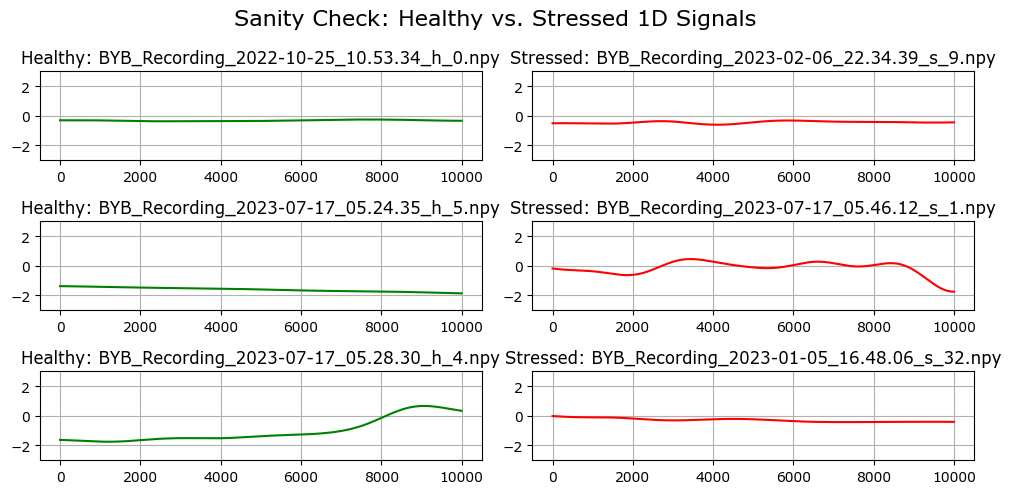

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

def visualize_signals():
    processed_dir = Path("../data/processed/solanum")
    healthy_dir = processed_dir / "healthy"
    stressed_dir = processed_dir / "stressed"

    if not healthy_dir.exists() or not stressed_dir.exists():
        print("Directories not found. Make sure you run this from the src/ folder.")
        return

    healthy_files = list(healthy_dir.glob("*.npy"))
    stressed_files = list(stressed_dir.glob("*.npy"))

    # Pick 3 random files from each class
    sample_healthy = random.sample(healthy_files, 3)
    sample_stressed = random.sample(stressed_files, 3)

    fig, axes = plt.subplots(3, 2, figsize=(10, 5))
    fig.suptitle("Sanity Check: Healthy vs. Stressed 1D Signals", fontsize=16)

    for i in range(3):
        # Plot Healthy
        h_signal = np.load(sample_healthy[i])
        axes[i, 0].plot(h_signal, color='green')
        axes[i, 0].set_title(f"Healthy: {sample_healthy[i].name}")
        axes[i, 0].set_ylim(-3, 3) # Standardized Y-axis for z-score comparison
        axes[i, 0].grid(True)

        # Plot Stressed
        s_signal = np.load(sample_stressed[i])
        axes[i, 1].plot(s_signal, color='red')
        axes[i, 1].set_title(f"Stressed: {sample_stressed[i].name}")
        axes[i, 1].set_ylim(-3, 3)
        axes[i, 1].grid(True)

    plt.tight_layout()
    plt.savefig("../signal_check.png")
    print("Saved visualization to ../signal_check.png")
    plt.show()

if __name__ == "__main__":
    visualize_signals()